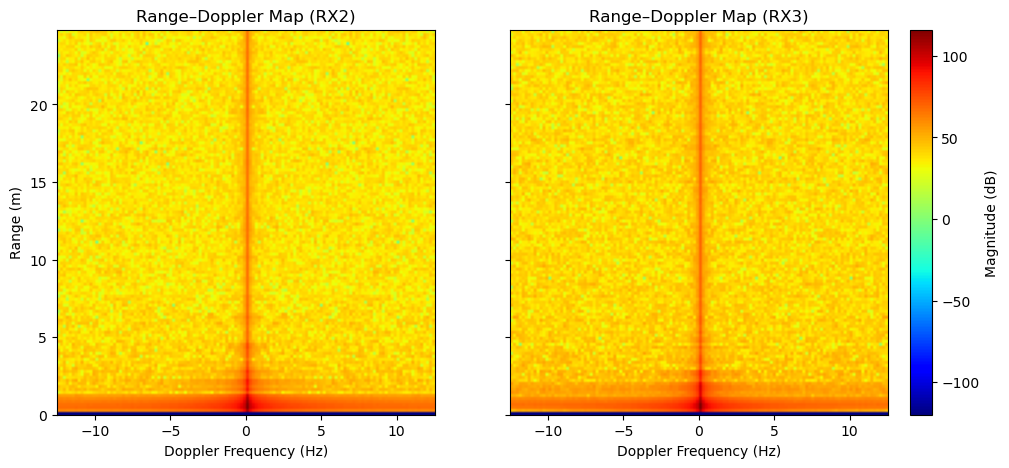

In [53]:
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def convert_to_data_frame(matlabFilePath, variableName):
    matData = scipy.io.loadmat(matlabFilePath)
    xdata = matData[variableName]

    df = pd.DataFrame(xdata)
    df = df.transpose()
    df.columns = ['RX0', 'RX1', 'RX2', 'RX3']
    return df

# Assume adcData is a DataFrame with shape [numADCSamples*numChirps, numRx]
# Each column = RX channel, each row = one sample in time

# Parameters
numADCSamples = 256
numChirps = 1024
Nfft_range = 256
Nfft_doppler = 128
Fs = 10e6          # sampling rate (Hz)
c = 3e8           # speed of light (m/s)
slope = 29.982e12     # chirp slope (Hz/s)
fc = 77e9         # carrier frequency (Hz) typical for mmWave radar
chirpPeriod = 40e-3  # chirp duration (s) -> 40ms
chirpRate = 1 / chirpPeriod  # chirp repetition frequency (Hz)

def doppler_range_two_channels_common_y(df, rx_list):
    # Create subplots with equal size and shared y-axis
    fig, axs = plt.subplots(
        1, 2, figsize=(11, 5), sharey=True, constrained_layout=False
    )

    # Loop through the two RX channels
    for i, rx in enumerate(rx_list):
        rx_series = df[rx]
        rx_matrix = rx_series.values.reshape(numChirps, numADCSamples)

        # Range FFT
        window_range = np.hamming(numADCSamples)
        rx_matrix = rx_matrix * window_range
        rx_matrix = rx_matrix - rx_matrix.mean(axis=1, keepdims=True)

        rangeFFT = np.fft.fft(rx_matrix, n=Nfft_range, axis=1)
        rangeFFT = np.abs(rangeFFT[:, :Nfft_range//2])

        # Doppler FFT
        window_doppler = np.hamming(numChirps)
        rangeFFT_win = rangeFFT * window_doppler[:, np.newaxis]
        dopplerFFT = np.fft.fftshift(
            np.fft.fft(rangeFFT_win, n=Nfft_doppler, axis=0),
            axes=0
        )
        dopplerFFT = np.abs(dopplerFFT)

        # Axes
        freqAxis_range = np.arange(Nfft_range//2) * (Fs / Nfft_range)
        rangeAxis = (c * freqAxis_range) / (2 * slope)
        dopplerAxis = np.linspace(-chirpRate/2, chirpRate/2, Nfft_doppler)

        # Plot each RX channel
        im = axs[i].imshow(
            20*np.log10(dopplerFFT.T+1e-6),
            extent=[dopplerAxis[0], dopplerAxis[-1], rangeAxis[0], rangeAxis[-1]],
            aspect='auto', origin='lower', cmap='jet'
        )
        axs[i].set_title(f"Range–Doppler Map ({rx})")
        axs[i].set_xlabel("Doppler Frequency (Hz)")
        if i == 0:
            axs[i].set_ylabel("Range (m)")

    # Adjust subplot area to leave room for colorbar
    fig.subplots_adjust(right=0.88)

    # Add ONE shared colorbar outside the plots
    cbar_ax = fig.add_axes([0.9, 0.11, 0.02, 0.77])  # [left, bottom, width, height]
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label("Magnitude (dB)")

    plt.show()

adcData = convert_to_data_frame(r'C:\Users\kavin\20250110\_5\_1\adc_data.mat', 'ans')
doppler_range_two_channels_common_y(adcData, ['RX2', 'RX3'])